In [1]:
from pathlib import Path
import numpy as np
import numpy.ma as ma
from datetime import datetime, timedelta
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import List, Tuple, Optional

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Path to sample data

In [ ]:
# modify the fo.lowing paths to match your local setup
DATA_DIR = Path('~/Desktop/opera_dist_test_prod').expanduser()
COMP_BASELINE_CONF = DATA_DIR / 'compute_bline/OPERA_L3_DIST-ALERT-S1_T11SLT_20250121T135246Z_20250604T091805Z_S1_30_v0.1'
print("Directory exists:", COMP_BASELINE_CONF.exists())
PREV_PROD_CONF = DATA_DIR / 'use_prev_prod/OPERA_L3_DIST-ALERT-S1_T11SLT_20250121T135246Z_20250604T163533Z_S1_30_v0.1'
print("Directory exists:", PREV_PROD_CONF.exists())

In [ ]:
# prefixes for product files
prev_prod_prefix = {
    'GEN-DIST-STATUS.tif',
    'GEN-DIST-STATUS-ACQ.tif',
    'GEN-METRIC.tif',
    'GEN-METRIC-MAX.tif',
    'GEN-DIST-CONF.tif',
    'GEN-DIST-DATE.tif',
    'GEN-DIST-COUNT.tif',
    'GEN-DIST-PERC.tif',
    'GEN-DIST-DUR.tif',
    'GEN-DIST-LAST-DATE.tif',
    }

comp_bline_prefix = {
    'GEN-DIST-STATUS.tif',
    'GEN-DIST-STATUS-ACQ.tif',
    'GEN-METRIC.tif',
}

### Load data

In [ ]:
# Read porduct as dictionary
def read_all_tiffs_as_dict(directory):
    arrays = {}
    for tif_path in Path(directory).glob("*.tif"):
        with rasterio.open(tif_path) as src:
            arrays[tif_path.name] = src.read(1)  # Band 1
    return arrays

def get_array_by_suffix(data_dict, suffix):
    for fname, array in data_dict.items():
        if fname.endswith(suffix):
            return array
    raise ValueError(f"No file ending with '{suffix}' found.")

In [42]:
# Read data for both sample products
comp_bline_dict = read_all_tiffs_as_dict(COMP_BASELINE_CONF)
print("Compute baseline confirmation product files:", len(comp_bline_dict.keys()))
prev_prod_dict = read_all_tiffs_as_dict(PREV_PROD_CONF)
print("Use previous confirmation product files:", len(prev_prod_dict.keys()))

Compute baseline confirmation product files: 3
Use previous confirmation product files: 10


In [51]:
# Display
DIST_CMAP = {
    0: (18, 18, 18, 255),
    1: (0, 85, 85, 255),
    2: (137, 127, 78, 255),
    3: (222, 224, 67, 255),
    4: (0, 136, 136, 255),
    5: (228, 135, 39, 255),
    6: (224, 27, 7, 255),
    7: (119, 119, 119, 255),
    8: (221, 221, 221, 255),
    255: (0, 0, 0, 255)
}

DIST_LABELS = {
    0: "No Disturbance",
    1: "First low",
    2: "Provisional low",
    3: "Confirmed low",
    4: "First high",
    5: "Provisional high",
    6: "Confirmed high",
    7: "Confirmed low finished",
    8: "Confirmed high finished",
    255: "NoData"
}

status_values = sorted(DIST_CMAP.keys())
rgba_colors = [tuple(np.array(DIST_CMAP[val]) / 255.0) for val in status_values]
status_cmap = mcolors.ListedColormap(rgba_colors)
status_norm = mcolors.BoundaryNorm(boundaries=np.array(status_values + [256]), ncolors=len(status_values))

def plot_layer(data_dict):
    for fname, array in data_dict.items():
        plt.figure(figsize=(8, 6))

        if fname.endswith(("GEN-DIST-STATUS.tif", "GEN-DIST-STATUS-ACQ.tif")):
            img = plt.imshow(array, cmap=status_cmap, norm=status_norm)
            cbar = plt.colorbar(img, ticks=status_values)
            cbar.ax.set_yticklabels([DIST_LABELS[val] for val in status_values])
            cbar.set_label('Status Category')

        elif fname.endswith("GEN-METRIC.tif"):
            img = plt.imshow(array, cmap='viridis')
            plt.colorbar(img, label='Metric Value')

        else:
            masked_array = ma.masked_equal(array, 255)
            img = plt.imshow(masked_array, cmap='copper')
            plt.colorbar(img, label='Value (255 = NoData)')

        plt.title(fname)
        plt.axis('off')
        plt.show()

### Visualize "Compute baseline confirmation" product

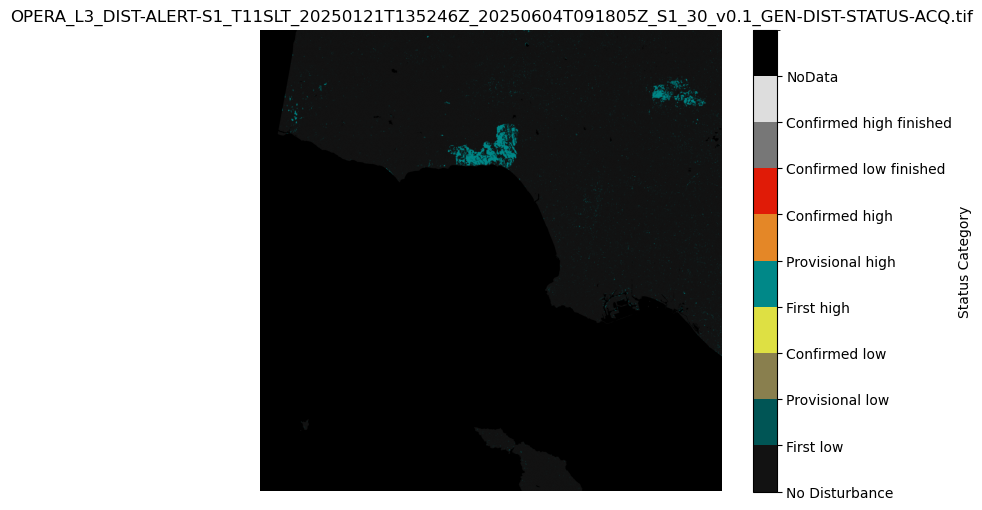

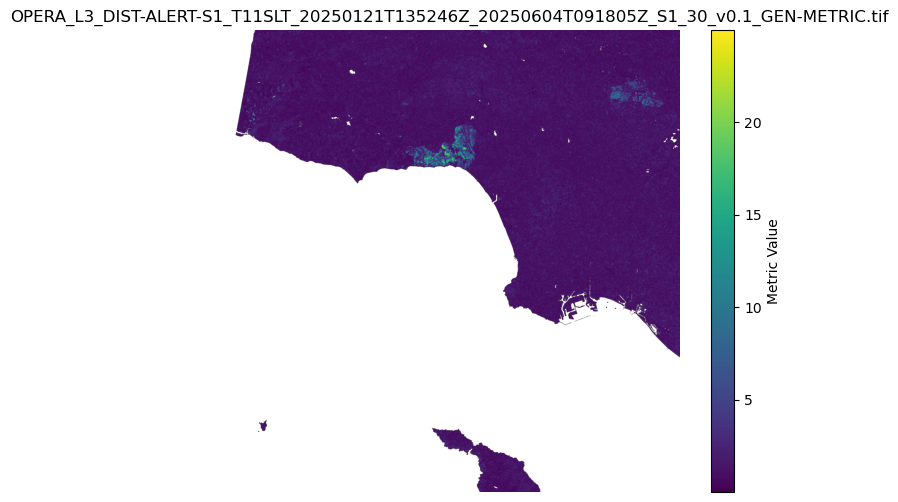

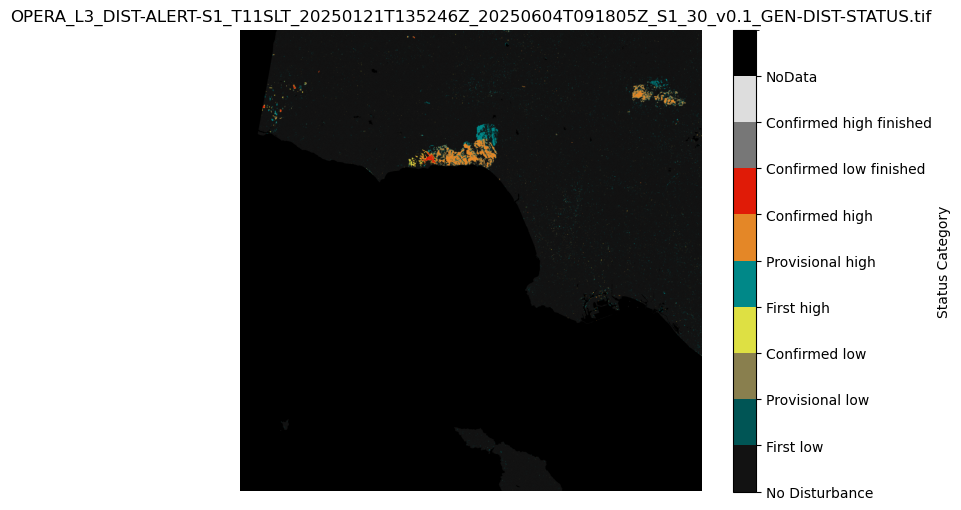

In [52]:
plot_layer(comp_bline_dict)

### Visualize "Use previous product confirmation" product

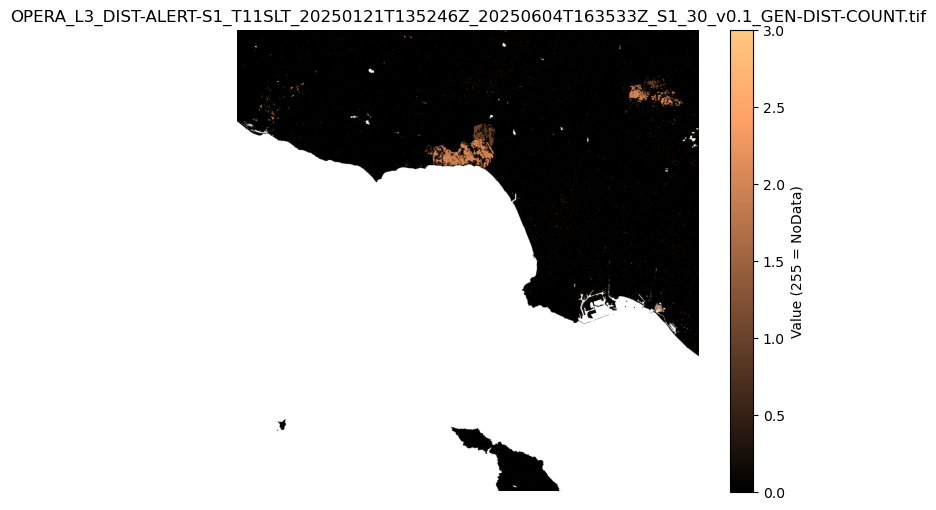

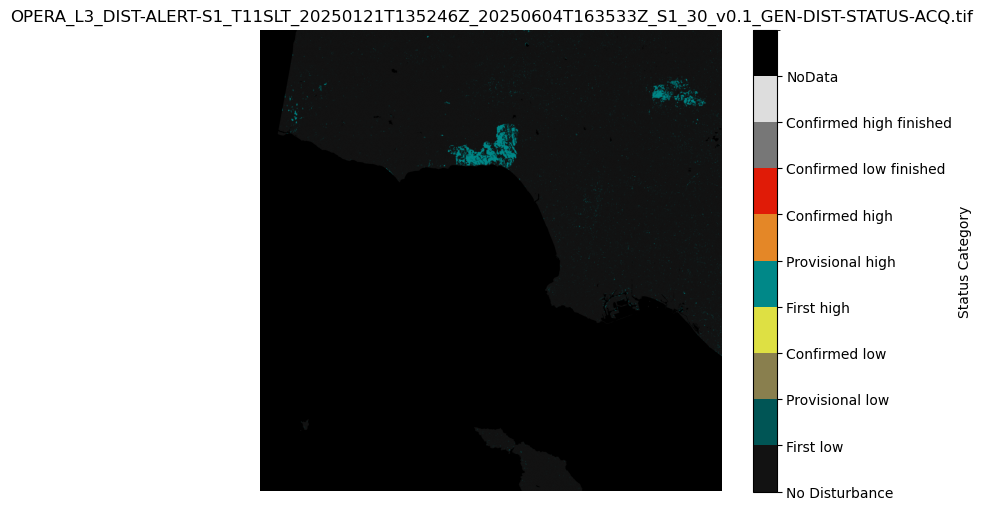

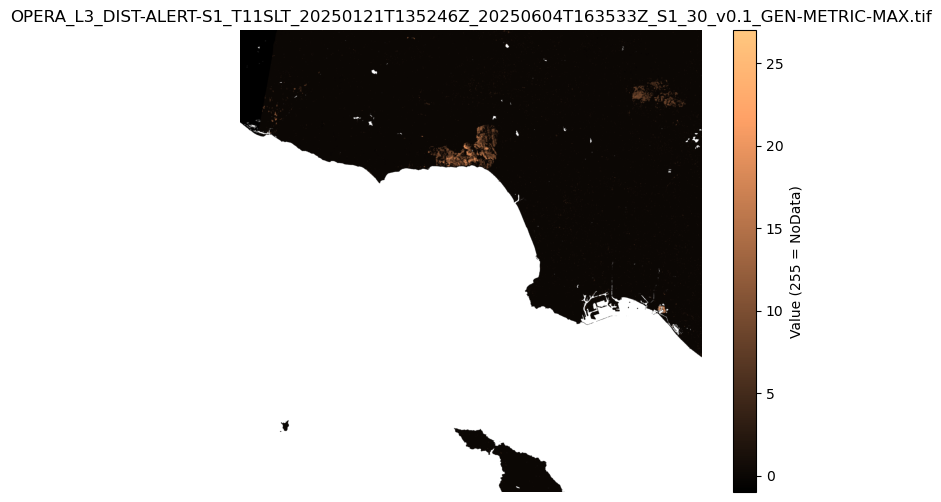

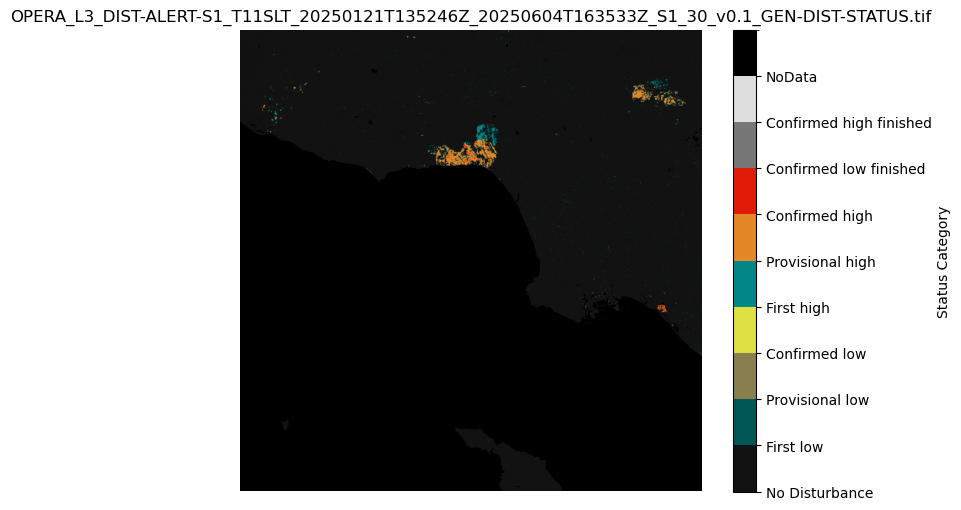

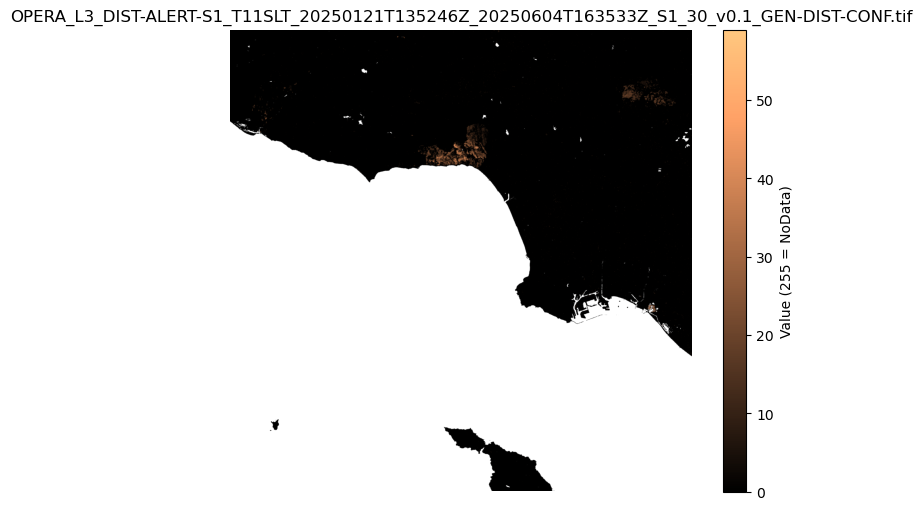

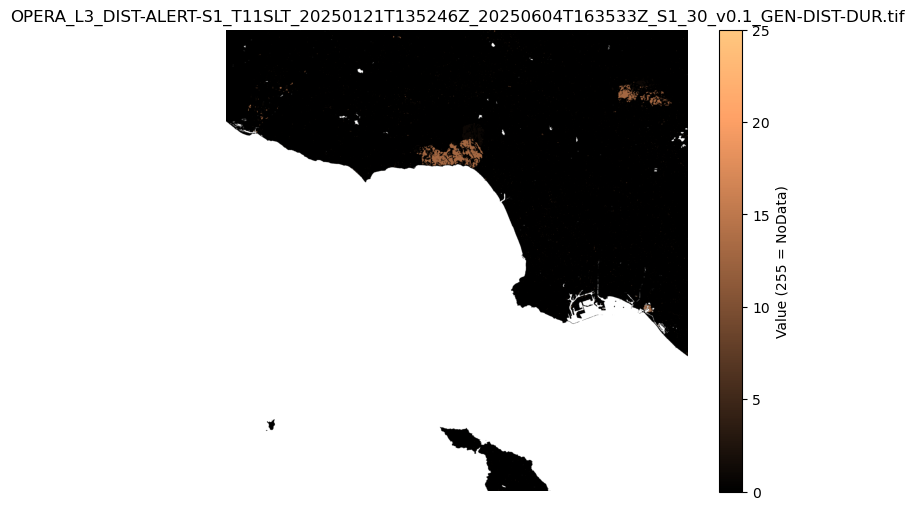

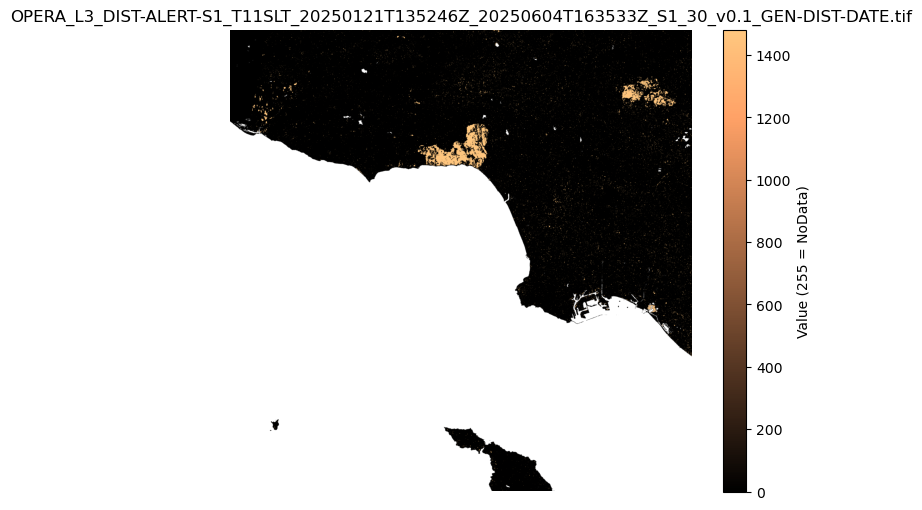

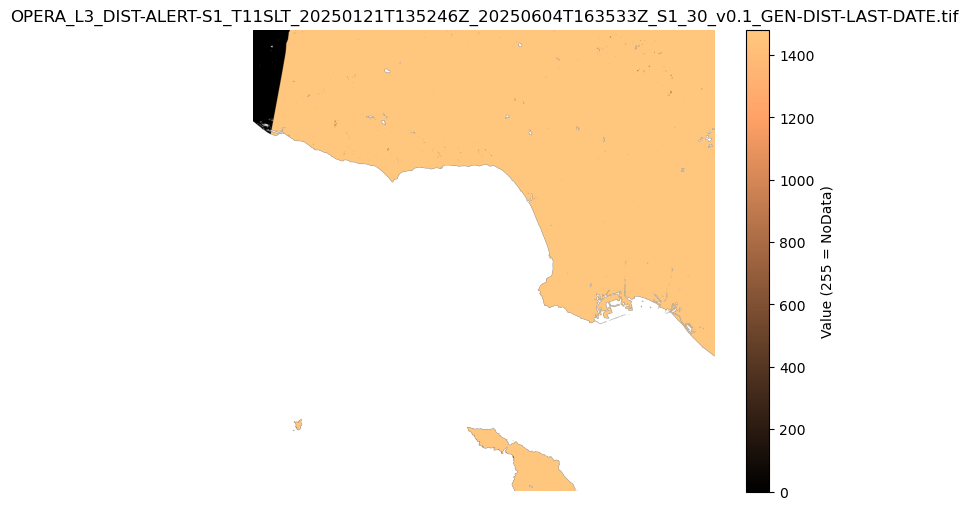

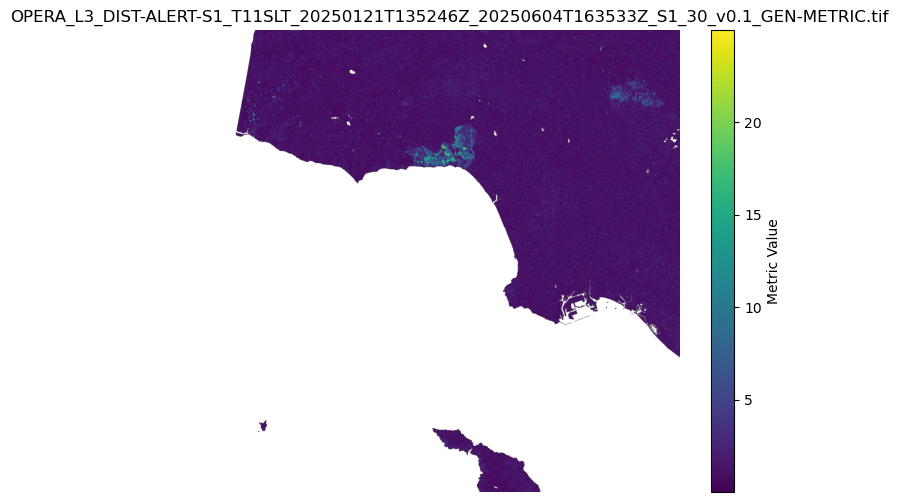

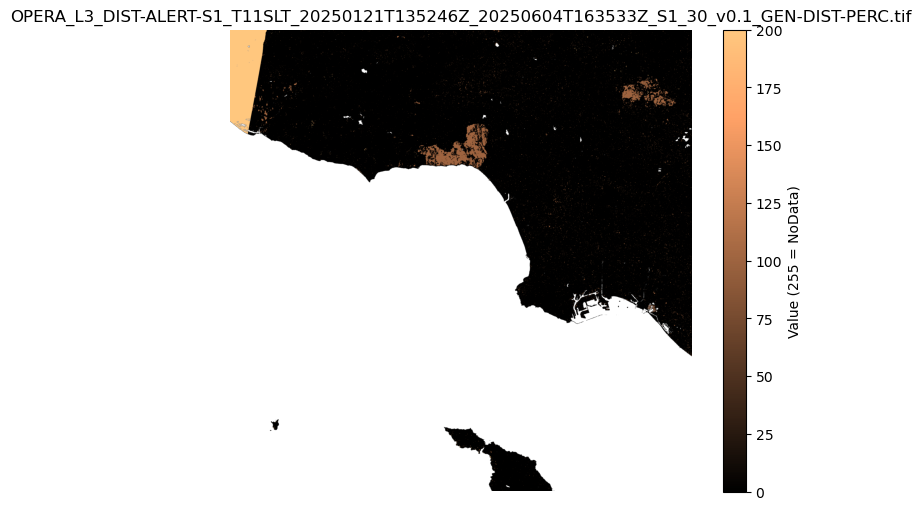

In [53]:
plot_layer(prev_prod_dict)